<a href="https://colab.research.google.com/github/ewst22ParkSY/ESAA11_PSY/blob/ESAA11_OB/ESAA_OB_WEEK3_2_transcript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. 가우시안 혼합

**가우시안 혼합 모델**Gaussian mixture model(GMM)
- 샘플이 파라미터가 알려지지 않은 여러 개의 혼합된 가우시안 분포에서 생성되었다고 가정하는 확률 모델
- 하나의 가우시안 분포에서 생성된 모든 샘플은 하나의 클러스터를 형성(보통 타원형)
- 각 클러스터는 타원의 모양, 크기, 밀집도, 방향이 다름
- 샘플이 주어지면 가우시안 분포 중 하나에서 생성되었다는 것을 알지만 어떤 분포인지 또 이 분포의 파라미터는 무엇인지 알지 못함.

여러 GMM 변종
- 가장 간단한 버전: ```GaussianMixture```
> - 사전에 가우시안 분포의 개수 k를 알아야함.

하단: 확률 변수random variable 사이의 조건부 의존성conditional dependency의 구조 나타냄. <br>
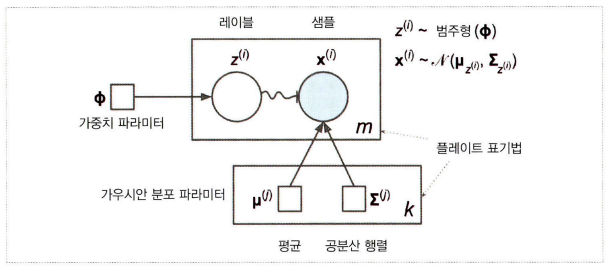

그림을 보는 방법
- 원: 확률변수
- 사각형: 고정값(= 모델의 파라미터)을 나타냄
- 큰 사각형: **플레이트**plate, 사각형 안의 내용이 여러 번 반복된다는 것을 나타냄
- 플레이트 오른쪽 아래 숫자: 플레이트 안의 내용 반복 횟수
- 각 변수 $z^{(i)}$: 가중치를 갖는 범주형 분포에서 샘플링
- 실선 화살표: 조건부 의존성
- $z^{(i)}에서 x^{(i)}$까지 구불구불한 화살표: 스위치
- 색이 채워진 원: 알려진 값

In [1]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise= 0.05)

In [2]:
from sklearn.mixture import GaussianMixture
gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10)

In [3]:
gm.weights_

array([0.60799488, 0.20334321, 0.18866191])

In [4]:
gm.means_

array([[ 0.48193082,  0.2681286 ],
       [ 1.73942441, -0.05685092],
       [-0.77765899,  0.5318264 ]])

In [5]:
gm.covariances_

array([[[ 0.17927122, -0.11414912],
        [-0.11414912,  0.29287289]],

       [[ 0.05387989,  0.06269927],
        [ 0.06269927,  0.08940709]],

       [[ 0.03935319,  0.05040965],
        [ 0.05040965,  0.08090205]]])

**기댓값-최대화**expectation-maximization(EM) 알고리즘을 사용함.
- k-평균 알고리즘과 공통점이 많음.
> 클러스터 파라미터를 랜덤하게 초기화 > 수렴할때까지 두 단계(샘플에 클러스터 할당-**기댓값 단계**- > 클러스터 업데이트-**최대화 단계**)를 반복
- EM은 하드 클러스터 할당이 아닌 소프트 클러스터 할당 사용

ex)
1. 기댓값 단계에서 각 클러스터에 속할 확률 예측
2. 최대화 단계에서 각 클러스터가 데이터셋에 있는 모든 샘플을 사용해 업데이트
3. 클러스터에 속할 추정 확률(= 샘플에 대한 클러스터의 **책임**responsibility)로 샘플에 가중치 적용<br>

- 최대화 단계에서 클러스터 업데이트는 책임이 가장 많은 샘플에 크게 영향을 받음.
- 알고리즘이 수렴했는지 여부와 반복 횟수를 확인할 수 있음.

In [6]:
gm.converged_

True

In [7]:
gm.n_iter_

20

- 하드 군집: ```predict()``` 메서드를 사용
- 소프트 군집: ```predict_proba()``` 메서드 사용

In [8]:
gm.predict(X)

array([2, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 2, 1, 0, 2, 0, 0, 0,
       0, 2, 1, 1, 0, 0, 0, 1, 2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0,
       2, 2, 0, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 0, 0, 2, 0, 1, 0, 1, 2, 1, 0, 0, 2, 0, 2, 0, 2, 2, 1, 0, 1,
       0, 1, 1, 1, 2, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2,
       0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 1, 1, 2, 0,
       1, 1, 0, 0, 0, 2, 0, 1, 2, 2, 2, 2, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0,
       1, 0, 2, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0, 1,
       0, 2, 0, 0, 2, 0, 1, 0, 0, 1, 1, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 0, 0, 1, 2,
       2, 2, 1, 1, 0, 2, 0, 2, 2, 2, 1, 0, 0, 1, 1, 0, 1, 0, 2, 2, 0, 0,
       0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [9]:
gm.predict_proba(X)

array([[1.31607292e-003, 2.23493758e-190, 9.98683927e-001],
       [9.01656154e-002, 1.77352060e-183, 9.09834385e-001],
       [9.63178250e-004, 1.80156030e-169, 9.99036822e-001],
       ...,
       [1.00000000e+000, 3.94700039e-080, 7.53573047e-027],
       [1.46596916e-003, 9.98534031e-001, 9.31340781e-229],
       [1.00000000e+000, 1.26678697e-017, 3.29311884e-110]])

가우시안 혼합 모델은 **생성 모델** generative model
> 이 모델에서 새로운 샘플을 만들 수 있음.

In [10]:
X_new, y_new = gm.sample(6)

print('X_new \n', X_new)
print('---------------')
print('y_new \n', y_new)

X_new 
 [[ 0.1205966  -0.44493904]
 [-0.11828591  0.0756217 ]
 [ 1.15138368  0.41301328]
 [ 0.50482228  0.37954486]
 [ 1.66734051 -0.13369776]
 [ 2.33242499  0.50024526]]
---------------
y_new 
 [0 0 0 0 1 1]


주어진 위치에서 모델의 밀도 추정 가능.
> ```score_samples()```메서드를 사용.
> - 그 위치의 **확률 밀도 함수**probability density function의 로그 예측. *점수가 높을수록 밀도가 높음.*



In [11]:
gm.score_samples(X)

array([ 1.29027235e-01, -8.97023161e-01, -1.75528617e+00, -1.68455011e+00,
       -8.14889588e-01, -1.49867883e+00, -1.18217847e+00, -2.03761004e+00,
       -1.88868834e+00, -1.65369331e+00, -1.79894567e+00, -1.99427231e+00,
       -6.88228955e-01, -4.78604158e-01, -1.67527618e+00, -3.62229909e-01,
       -6.62648342e-01, -1.61602852e+00, -2.01401228e-01, -1.41835663e+00,
       -2.24020916e+00, -1.76703200e+00, -1.72448268e+00, -9.13129804e-01,
       -1.07920946e+00, -1.12393400e-01, -1.92292540e+00, -2.02007254e+00,
       -1.41352691e+00, -1.43664070e-01,  1.24639502e-01, -1.78850377e+00,
       -6.05059060e-02, -4.78528074e-01, -1.46405337e+00, -1.97155917e+00,
       -1.65001982e+00, -1.04306142e+00, -1.62451182e+00, -2.31759698e+00,
       -1.81370105e+00, -1.49680607e+00, -2.11620166e+00, -1.68169689e+00,
       -5.04157905e-01, -8.30425195e-01, -1.43444914e+00, -7.51716956e-01,
       -1.63688910e-01, -1.99319410e-01, -1.26385428e+00, -1.28514365e+00,
       -1.61670768e+00, -

점수의 지숫값 계산시 샘플의 위치에서 PDF 값을 얻을 수 있음. (이 값은 하나의 확률이 아닌 확률 밀도. 0에서 1까지의 값이 아니라 어떤 양숫값도 될 수 있음.)
- 샘플의 특정 지역 안에 속할 확률을 예측하려면 그 지역에 대해 PDF를 적분. (가능한 샘플 위치 전 지역에 대해 적분해 더하면 1)

- 특성이나 클러스터가 많거나 샘플이 적을 때는 EM이 최적의 솔루션으로 수렴하기 어려움.
- 방법: 작업의 어려움을 줄이기 위해서 알고리즘이 학습할 파라미터 개수를 제한해야 함.
> 클러스터의 모양과 방향의 범위 제한
> 공분산 행렬에 제약을 추가

covariance_type 매개변수에 다음 값 중 하나를 설정
- spherical: 모든 클러스터가 원형, 지름은 다를 수 있음.(분산이 다름)
- diag: 클러스터는 크기에 상관없이 어떤 타원형도 가능. (타원의 축은 좌표 축과 나란해야 함. = 공분산 행렬이 대각 행렬이어야 함.)
- tied: 모든 클러스터가 동일한 타원 모양, 크기, 방향을 가짐. (모든 클러스터는 동일한 공분산 행렬을 공유)

```covariance_type``` 매개변수의 기본값은 ```"full"```임.
- 모양, 크기, 방향에 제약이 없음.(각자 제약이 없는 공분산 행렬을 가짐.)

covariance_type의 값에 따라 다른 EM 알고리즘으로 찾은 솔루션 <br>
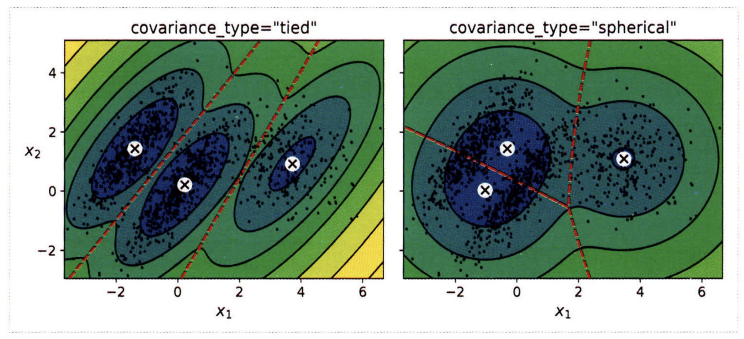

### 2.1 가우시안 혼합을 사용한 이상치 탐지

**이상치 탐지**outlier detection
- 보통과 많이 다른 샘플(=**이상치**outlier)을 감지하는 작업
> 보통 샘플은 **정상치**inlier라고 함.
- 사용 예) 부정 거래 감지, 제조 결함이 있는 제품 감지, 다른 모델 훈련 전 데이터셋 이상치 제거(> 최종 모델 성능 향상)

가우시안 혼합 모델을 이상치 탐지에 사용하는 방법
- 밀도가 낮은 지역에 있는 모든 샘플을 이상치로 봄.
> 이렇게 하기 위해선 밀도 임곗값을 정함.
> 일반적인 정밀도/재현율 트레이드 오프.

In [13]:
import numpy as np
# 네 번째 백분위수(4%)를 밀도 임계값으로 사용하여 이상치를 구분하는 방법

densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 4)
anomalies = X[densities < density_threshold]

**특이치 탐지**novelty detection
- 이상치로 오염되지 않은 '깨끗한' 데이터셋에서 훈련한다는 점이 이상치 탐지와 다른점.
- 이상치 탐지: 데이터셋 정제하는데 사용

### 2.2 클러스터 개수 선택하기
- k-평균에서는 이너셔나 실루엣 점수를 사용해 적절한 클러스터 개수를 선택. (가우시안 혼합에서는 이런 지표 사용 X << 클러스터가 타원형이거나 크기가 다를 때 안정적이지 않기 때문)
- 대신 정의된 **BIC**Bayesian information criterion나 **AIC**Akaike information criterion와 같은 **이론적 정보 기준**theoretical information criterion을 최소화하는 모델 찾음

BIC와 AIC <br>
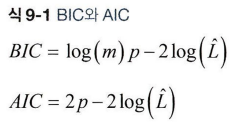

- $m$: 샘플의 개수
- $p$: 모델이 학습할 파라미터 개수
- $\hat{L}$: 모델의 **가능도 함수**lidelihood funciton의 최댓값

BIC와 AIC
- 학습할 파라미터가 많은 모델에게 벌칙을 가하고 데이터에 잘 학습하는 모델에게 보상을 더함
- 종종 동일한 모델을 선택하나, 둘의 선택이 다를 경우 AIC가 간단한 경향이 있음. (데이터에 아주 잘 맞지 않을 수 있음.)

가능도 함수: 확률과 가능도는 구별없이 사용되나, '확률'은 파라미터 $\theta$인 확률 모델이 주어졌을 때 미래 출력 x가 얼마나 그럴듯 한지를 설명, '가능도'는 출력 x를 알고 있을 때 특정 파라미터 값 $\theta$가 얼마나 그럴듯한지 설명.

PDF는 $x$의 함수. ($\theta$ 고정) <br>
가능도 함수는 $\theta$의 함수. ($x$ 고정)

In [14]:
# BIC AIC 계산

print('bic() : ', gm.bic(X))
print('aic() : ', gm.aic(X))

bic() :  2767.7555270743946
aic() :  2684.3236873316982


### 2.3 베이즈 가우시안 혼합 모델
- 최적의 클러스터 개수를 수동으로 찾지 않고 불필요한 클러스터의 가중치를 0으로 만드는 ``` BayesianGaussianMixture``` 클래스 사용.
- 클러스터 개수 n_components를 최적의 클러스터 개수보다 크다고 믿을 만한 값으로 지정
- 자동으로 클러스터 제거

In [15]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, n_init=10)
bgm.fit(X)
np.round(bgm.weights_, 2)

/usr/local/lib/python3.11/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


array([0.13, 0.13, 0.09, 0.17, 0.16, 0.1 , 0.1 , 0.11, 0.  , 0.  ])

- 클러스터 파라미터(가중치, 평균, 공분산 행렬 등)는 더는 고정된 모델 파라미터가 아닌 클러스터 할당처럼 잠재 확률 변수로 취급.

**베타 분포**beta distribution는 고정 범위 안에 놓인 값을 가진 확률 변수를 모델링할 때 자주 사용 (0 ~ 1 범위)

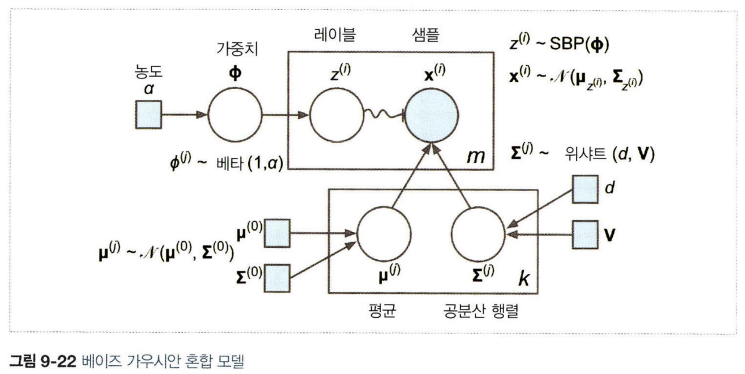

- 잠재 변수 z에 대한 사전 지식이 **사전 확률**prior이라는 확률 분포 $p(z)$에 인코딩 될 수 있음.
- 클러스터가 적을 것이라는 **사전 믿음**prior belif(낮은 농도)를 가질 수 있음. or 풍부하다고 믿을 수 있음.
> 클러스터 개수에 대한 사전믿음은 weight_concentration_prior 매개변수를 사용해 조정
> 하지만 데이터가 많을수록 사전 믿음은 중요하지 않음.

- 베이즈 정리는 데이터 X를 관측하고 난 후 잠재 변수에 대한 확률 분포를 업데이트 하는 방법을 설명.
> X가 주어졌을 때 z의 조건부 확률인 **사후 확률** posterior **분포** $p(z|X)$를 계산.

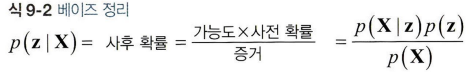

- 가우시안 혼합 모델에서 분모인 p(X)는 계산하기 힘듦. (가능한 모든 z값에 대해 적분해야 하기 때문.)
> 해결 방법
> **변분 추론** variational inference <br>
> 자체적인 **변분 파라미터** variational parameter **λ**를 가진 분포 패밀리 선택, 파라미터를 최적화 후 KL 발산을 최소화하는 **λ**값을 찾아 해결.
>> KL발산 최소화: ELBO 최대화

ELBO 최대화
- **평균장 변분 추론**mean field variational inference에서 ELBO 식을 계산할 수 있는 형태로 단순화하기 위해 분포 패밀리와 사전 확률을 매우 주의 깊게 선택.
- **블랙 박스 확률적 변분 추론**black box stochastic variational inference

### 2.4 이상치 탐지와 특이치 탐지를 위한 다른 알고리즘
- PCA(그리고 inferse_transform() 메서드를 가진 다른 차원 축소 기법)
- Fast_MCD minimum covariance determinant
- 아이솔레이션 포레스트
- LOF local outlier factor
- one-class SVM